# Fact-Check SFT Training And Comparison

This notebook fine-tunes the existing prompt/completion dataset and compares the base model against the fine-tuned model on a held-out eval split.

What it does:
- loads `training_pairs.json`
- splits the dataset into train and eval sets
- evaluates the base model on the held-out eval set
- fine-tunes with LoRA / QLoRA using `SFTTrainer`
- evaluates the fine-tuned model on the same eval set
- prints a small comparison table

Notes:
- This version is simplified for Google Colab.
- Set the Drive path and Hugging Face token directly in the config cell.
- The current dataset contains `TRUE`, `FALSE`, and `MISLEADING`.


In [1]:
%pip install --quiet -U bitsandbytes accelerate transformers peft trl datasets

In [2]:
from pathlib import Path
import json
import os
import random
import re
import sys

from google.colab import userdata
import numpy as np
import pandas as pd
import torch
from huggingface_hub import login
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, BitsAndBytesConfig
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer
from datasets import Dataset
import matplotlib.pyplot as plt


In [3]:
# Quick hardware check. In Colab this should show the assigned GPU if one is attached.
print('cuda_available =', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu_name =', torch.cuda.get_device_name(0))
else:
    print('No GPU detected')
print("bitsandbytes version:", bnb.__version__)
print("transformers version:", transformers.__version__)

cuda_available = True
gpu_name = NVIDIA A100-SXM4-80GB


In [6]:
# Colab-first config. Edit these values directly for your Drive setup.
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

# Change this to your actual Drive repo/project folder.
PROJECT_ROOT = Path('/content/drive/MyDrive/AIGColab/NLP/FinalProject') if IN_COLAB else (Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from config.model_config import MODEL_CONFIG
except Exception:
    MODEL_CONFIG = {
        'base_model': 'meta-llama/Llama-3.1-8B-Instruct',
        'max_length': 4096,
        'batch_size': 4,
        'gradient_accumulation_steps': 4,
        'learning_rate': 2e-4,
        'num_epochs': 3,
        'warmup_steps': 100,
        'logging_steps': 10,
        'save_steps': 500,
        'output_dir': str(PROJECT_ROOT / 'models' / 'factcheck-llama-canadian'),
        'lora_r': 16,
        'lora_alpha': 32,
        'lora_dropout': 0.05,
        'target_modules': ['q_proj', 'v_proj', 'k_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
    }

# Edit these directly if needed.
HF_TOKEN = userdata.get("HF_TOKEN")
DATA_PATH = PROJECT_ROOT / 'data' / 'training_pairs.json'
MODEL_OUTPUT_DIR = PROJECT_ROOT / 'models' / 'factcheck-sft-notebook'
BASE_MODEL = MODEL_CONFIG['base_model']
RANDOM_SEED = 42
TRAIN_SIZE = 0.9
MAX_EVAL_SAMPLES = 120
REPORT_TO = 'none'

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print('in_colab =', IN_COLAB)
print('project_root =', PROJECT_ROOT)
print('training_data =', DATA_PATH)
print('base_model =', BASE_MODEL)
print('model_output_dir =', MODEL_OUTPUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
in_colab = True
project_root = /content/drive/MyDrive/AIGColab/NLP/FinalProject
training_data = /content/drive/MyDrive/AIGColab/NLP/FinalProject/data/training_pairs.json
base_model = meta-llama/Llama-3.1-8B-Instruct
model_output_dir = /content/drive/MyDrive/AIGColab/NLP/FinalProject/models/factcheck-sft-notebook


In [7]:
# Load the prepared SFT rows.
with DATA_PATH.open('r', encoding='utf-8') as f:
    training_rows = json.load(f)

print('Rows loaded:', len(training_rows))
print('Keys:', list(training_rows[0].keys()))
print('Sample verdict:', training_rows[0]['completion'].splitlines()[0])
print('Sample metadata label:', (training_rows[0].get('metadata') or {}).get('label'))


Rows loaded: 1128
Keys: ['prompt', 'completion', 'metadata']
Sample verdict: VERDICT: TRUE
Sample metadata label: TRUE


In [8]:
VERDICT_RE = re.compile(r'^VERDICT:\s*(TRUE|FALSE|MISLEADING|UNVERIFIED)', re.MULTILINE)
VALID_LABELS = ['TRUE', 'FALSE', 'MISLEADING', 'UNVERIFIED']


def parse_verdict(text: str) -> str:
    match = VERDICT_RE.search(text or '')
    return match.group(1).upper() if match else 'INVALID'


def format_dataset(rows: list, tokenizer):
    """Turn prompt/completion pairs into chat-formatted training text."""
    formatted_rows = []
    for item in rows:
        conversation = [
            {
                'role': 'system',
                'content': 'You are a fact-checking assistant specializing in Canadian parliamentary debates. Verify claims using reliable sources and provide evidence-based assessments.'
            },
            {'role': 'user', 'content': item['prompt']},
            {'role': 'assistant', 'content': item['completion']},
        ]
        formatted_rows.append({
            'text': tokenizer.apply_chat_template(conversation, tokenize=False)
        })
    return Dataset.from_list(formatted_rows)


def build_prompt_only_text(item: dict, tokenizer) -> str:
    """Build the inference prompt without the gold completion."""
    conversation = [
        {
            'role': 'system',
            'content': 'You are a fact-checking assistant specializing in Canadian parliamentary debates. Verify claims using reliable sources and provide evidence-based assessments.'
        },
        {'role': 'user', 'content': item['prompt']},
    ]
    return tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)


def evaluate_model(model, tokenizer, rows: list, max_examples: int = MAX_EVAL_SAMPLES):
    """Generate verdicts on a held-out sample and return simple metrics."""
    eval_rows = rows[:max_examples]
    y_true = []
    y_pred = []
    records = []

    model.eval()
    for item in eval_rows:
        prompt_text = build_prompt_only_text(item, tokenizer)
        inputs = tokenizer(prompt_text, return_tensors='pt').to(model.device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=160,
                temperature=0.1,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        predicted = parse_verdict(generated_text)
        actual = parse_verdict(item['completion'])

        y_true.append(actual)
        y_pred.append(predicted)
        records.append({
            'claim_id': (item.get('metadata') or {}).get('claim_id'),
            'actual': actual,
            'predicted': predicted,
            'correct': actual == predicted,
        })

    label_order = VALID_LABELS + ['INVALID']
    report = classification_report(
        y_true,
        y_pred,
        labels=label_order,
        output_dict=True,
        zero_division=0,
    )

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'rows_evaluated': len(eval_rows),
        'invalid_predictions': sum(pred == 'INVALID' for pred in y_pred),
        'report': report,
        'confusion_matrix': confusion_matrix(y_true, y_pred, labels=label_order).tolist(),
        'label_order': label_order,
        'records': records,
    }
    return metrics


def show_confusion(metrics: dict, title: str):
    label_order = metrics['label_order']
    cm = np.array(metrics['confusion_matrix'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.show()


In [9]:
# Extract labels and create a simple stratified split.
labels = [parse_verdict(item['completion']) for item in training_rows]
label_counts = pd.Series(labels).value_counts().sort_index()
display(label_counts.rename_axis('label').reset_index(name='count'))

valid_rows = [item for item, label in zip(training_rows, labels) if label in VALID_LABELS]
valid_labels = [parse_verdict(item['completion']) for item in valid_rows]

train_rows, eval_rows = train_test_split(
    valid_rows,
    train_size=TRAIN_SIZE,
    random_state=RANDOM_SEED,
    stratify=valid_labels,
)

print('Train rows:', len(train_rows))
print('Eval rows:', len(eval_rows))
print('Eval sample size used for comparison:', min(MAX_EVAL_SAMPLES, len(eval_rows)))


,label,count
0,FALSE,500
1,MISLEADING,128
2,TRUE,500


Train rows: 1015
Eval rows: 113
Eval sample size used for comparison: 113


In [10]:
def setup_model(base_model: str):
    use_cuda = torch.cuda.is_available()
    gpu_name = torch.cuda.get_device_name(0).lower() if use_cuda else ""
    compute_dtype = torch.float16 if "t4" in gpu_name else torch.bfloat16

    model_kwargs = {"trust_remote_code": True}

    if use_cuda:
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=compute_dtype,
            bnb_4bit_use_double_quant=True,
        )
        model_kwargs["device_map"] = "auto"
        model_kwargs["dtype"] = compute_dtype
        model_kwargs["quantization_config"] = quantization_config
    else:
        model_kwargs["dtype"] = torch.float32
        print("CUDA not detected. The notebook will still run, but training will be slow on CPU.")

    model = AutoModelForCausalLM.from_pretrained(base_model, **model_kwargs)
    tokenizer = AutoTokenizer.from_pretrained(base_model)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    tokenizer.padding_side = 'right'

    if use_cuda:
        model = prepare_model_for_kbit_training(model)

    lora_config = LoraConfig(
        r=MODEL_CONFIG['lora_r'],
        lora_alpha=MODEL_CONFIG['lora_alpha'],
        target_modules=MODEL_CONFIG['target_modules'],
        lora_dropout=MODEL_CONFIG['lora_dropout'],
        bias='none',
        task_type='CAUSAL_LM',
    )

    model = get_peft_model(model, lora_config)
    return model, tokenizer


model, tokenizer = setup_model(BASE_MODEL)
train_dataset = format_dataset(train_rows, tokenizer)
eval_dataset = format_dataset(eval_rows, tokenizer)

print(train_dataset)
print('Base model loaded and datasets prepared.')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Dataset({
    features: ['text'],
    num_rows: 1015
})
Base model loaded and datasets prepared.


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


,model,accuracy,rows_evaluated,invalid_predictions
0,base,0.619469,113,0


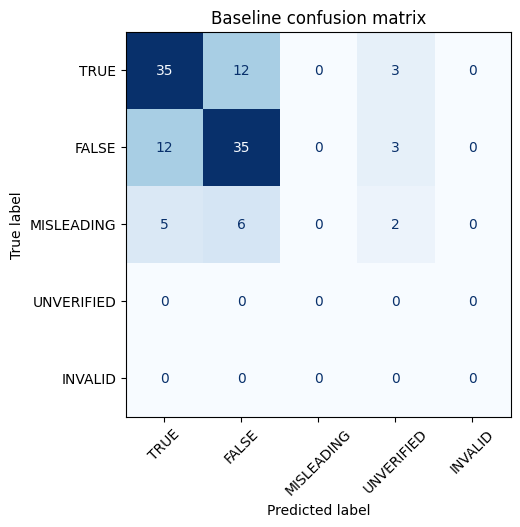

In [11]:
# Baseline evaluation before fine-tuning.
baseline_metrics = evaluate_model(model, tokenizer, eval_rows)
baseline_summary = pd.DataFrame([
    {
        'model': 'base',
        'accuracy': baseline_metrics['accuracy'],
        'rows_evaluated': baseline_metrics['rows_evaluated'],
        'invalid_predictions': baseline_metrics['invalid_predictions'],
    }
])
display(baseline_summary)
show_confusion(baseline_metrics, 'Baseline confusion matrix')

In [12]:
# Training setup. This cell prepares the trainer but does not train yet.
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

training_args = TrainingArguments(
    output_dir=str(MODEL_OUTPUT_DIR),
    num_train_epochs=MODEL_CONFIG['num_epochs'],
    per_device_train_batch_size=MODEL_CONFIG['batch_size'],
    gradient_accumulation_steps=MODEL_CONFIG['gradient_accumulation_steps'],
    learning_rate=MODEL_CONFIG['learning_rate'],
    warmup_steps=MODEL_CONFIG['warmup_steps'],
    logging_steps=MODEL_CONFIG['logging_steps'],
    save_steps=MODEL_CONFIG['save_steps'],
    save_total_limit=2,
    fp16=False,
    bf16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    report_to=REPORT_TO,
)

trainer = SFTTrainer(
    model=model,
    # tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=training_args,
    # max_seq_length=MODEL_CONFIG['max_length'],
)

print('Trainer is ready. Run the next cell manually when you want to start training.')


Adding EOS to train dataset:   0%|          | 0/1015 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1015 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1015 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/113 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/113 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/113 [00:00<?, ? examples/s]

Trainer is ready. Run the next cell manually when you want to start training.


In [13]:
# Start training manually.
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.


Step,Training Loss
10,2.402086
20,1.995285
30,1.436894
40,1.064622
50,0.943053
60,0.921458
70,0.864603
80,0.831313
90,0.825163
100,0.822608


TrainOutput(global_step=192, training_loss=1.0008063334971666, metrics={'train_runtime': 864.903, 'train_samples_per_second': 3.521, 'train_steps_per_second': 0.222, 'total_flos': 8.280560606598758e+16, 'train_loss': 1.0008063334971666})

In [14]:
# Save the trained adapter manually after training.
final_dir = MODEL_OUTPUT_DIR / 'final'
trainer.model.save_pretrained(final_dir)
tokenizer.save_pretrained(final_dir)

('/content/drive/MyDrive/AIGColab/NLP/FinalProject/models/factcheck-sft-notebook/final/tokenizer_config.json',
 '/content/drive/MyDrive/AIGColab/NLP/FinalProject/models/factcheck-sft-notebook/final/chat_template.jinja',
 '/content/drive/MyDrive/AIGColab/NLP/FinalProject/models/factcheck-sft-notebook/final/tokenizer.json')

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

,model,accuracy,rows_evaluated,invalid_predictions
0,fine_tuned,0.946903,113,0


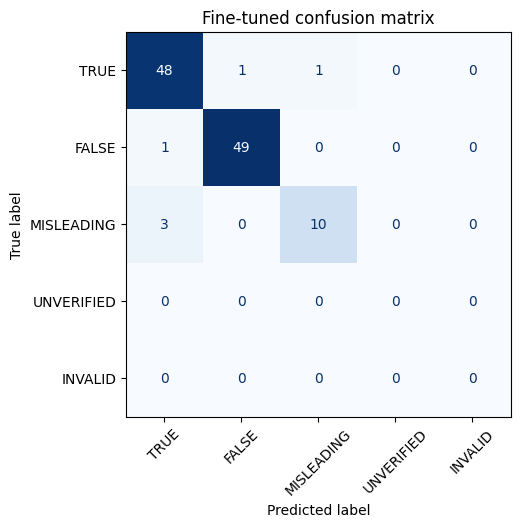

In [15]:
# Evaluate the fine-tuned adapter on the same held-out set after training.
final_dir = MODEL_OUTPUT_DIR / 'final'
base_for_eval = AutoModelForCausalLM.from_pretrained(BASE_MODEL, trust_remote_code=True, device_map='auto' if torch.cuda.is_available() else None, torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32)
finetuned_model = PeftModel.from_pretrained(base_for_eval, final_dir)
finetuned_metrics = evaluate_model(finetuned_model, tokenizer, eval_rows)
finetuned_summary = pd.DataFrame([{
    'model': 'fine_tuned',
    'accuracy': finetuned_metrics['accuracy'],
    'rows_evaluated': finetuned_metrics['rows_evaluated'],
    'invalid_predictions': finetuned_metrics['invalid_predictions'],
}])
display(finetuned_summary)
show_confusion(finetuned_metrics, 'Fine-tuned confusion matrix')

In [16]:
# Final comparison after baseline and fine-tuned evaluation are both available.
comparison = pd.concat([baseline_summary, finetuned_summary], ignore_index=True)
display(comparison)
comparison.to_csv(PROJECT_ROOT / 'data' / 'training_comparison.csv', index=False)

,model,accuracy,rows_evaluated,invalid_predictions
0,base,0.619469,113,0
1,fine_tuned,0.946903,113,0
